In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from preprocess import *
from utils import *
import numpy as np
import matplotlib.pyplot as plt
import harmonypy as hm
import anndata as ad

from matplotlib.image import imread
from train import Train

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [3]:
# savepath = 'Result'
# if not os.path.exists(savepath):
#     os.mkdir(savepath)

In [4]:
String = 'H'
n_cluster = 6

patho_anno = pd.read_csv(f"../../../data/BreastCancer/her2st-master/data/ST-pat/lbl/{String}1_labeled_coordinates.tsv", index_col=0, sep='\t')


adata_st_list_raw = []

for i in range(1, 4):
    # st_count = pd.read_csv("./data/HER2-positive/count-matrices/E%d.tsv.gz" % i, index_col=0, sep='\t')
    # st_meta = pd.read_csv("./data/HER2-positive/spot-selections/E%d_selection.tsv.gz" % i, sep='\t')
    st_count = pd.read_csv(f"../../../data/BreastCancer/her2st-master/data/ST-cnts/{String}{i}.tsv.gz", index_col=0, sep='\t')
    st_meta = pd.read_csv(f"../../../data/BreastCancer/her2st-master/data/ST-spotfiles/{String}{i}_selection.tsv", sep='\t')
    st_meta.index = [str(st_meta['x'][i]) + 'x' + str(st_meta['y'][i]) for i in range(st_meta.shape[0])]
    st_meta = st_meta.loc[st_count.index]
    
    adata_st_i = ad.AnnData(X=st_count.values)
    adata_st_i.obs.index = st_count.index
    adata_st_i.obs = st_meta
    adata_st_i.var.index = st_count.columns
    
    img = imread(f'../../../data/BreastCancer/her2st-master/data/ST-imgs/{String}/{String}{i}.jpg')
    library_id = 'st'
    adata_st_i.uns["spatial"] = dict()
    adata_st_i.uns["spatial"][library_id] = dict()
    adata_st_i.uns["spatial"][library_id]['images'] = dict()
    adata_st_i.uns["spatial"][library_id]['images']['hires'] = img
    adata_st_i.uns["spatial"][library_id]['images']['lowres'] = img
    adata_st_i.uns["spatial"][library_id]['scalefactors'] = {'spot_diameter_fullres': 100,
                                                             'tissue_hires_scalef': 1.0,
                                                             'fiducial_diameter_fullres': 100,
                                                             'tissue_lowres_scalef': 1.0}
    
    adata_st_i.obsm['spatial'] = np.concatenate((np.array(st_meta["pixel_x"]).reshape(-1,1),
                                                 np.array(st_meta["pixel_y"]).reshape(-1,1)), axis=1)

    adata_st_i.obsm['loc_use'] = np.concatenate((np.array(st_meta["x"]).reshape(-1,1),
                                                 np.array(st_meta["y"]).reshape(-1,1)), axis=1)
    adata_st_i.obs['array_row'] = adata_st_i.obs["x"].values
    adata_st_i.obs['array_col'] = adata_st_i.obs["y"].values
    adata_st_i.obs['st_sample'] = String + str(i)

    if i == 1:
        adata_st_i.obs['annotation'] = None
        for idx in adata_st_i.obs.index:
            adata_st_i.obs['annotation'].loc[idx] = patho_anno[(patho_anno["x"] == adata_st_i[idx].obs["new_x"].values[0]) &
                                                               (patho_anno["y"] == adata_st_i[idx].obs["new_y"].values[0])]['label'].values[0]
    else:
        adata_st_i.obs['annotation'] = "Unknown"
    
    print(f'Slice {String}{i} spots:' + str(len(adata_st_i.obs)))

    adata_st_list_raw.append(adata_st_i)

D:\anaconda\envs\njy\Lib\site-packages\PIL\Image.py:3186: DecompressionBombWarning: Image size (91791569 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_262972\1439680897.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_st_i.obs['annotation'].loc[idx] = patho_anno[(patho_anno["x"] == adata_st_i[idx].obs["new_x"].values[0]) &
C:\Users\DELL\AppData\Local\Temp\ipykernel_262972\1439680897.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_st_i.obs['annotation'].loc[idx] = patho_anno[(patho_anno["x"] == adata_st_i

Slice H1 spots:613
Slice H2 spots:603


D:\anaconda\envs\njy\Lib\site-packages\PIL\Image.py:3186: DecompressionBombWarning: Image size (92155591 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Slice H3 spots:510


In [5]:
slice_use = []
for i in range(1,4):
    slice_id = String + str(i)
    slice_use.append(slice_id)
slice_use

['H1', 'H2', 'H3']

In [6]:
datasets_df = pd.DataFrame([slice_use])
datasets_df.index = ['Sample1']
datasets_df.columns = ['Location1', 'Location2', 'Location3']
batch_tag = 'Sample1'
datasets = datasets_df.loc[batch_tag].values    # Sample
# datasets = datasets_df[batch_tag].values        # Location
dataset_tags = datasets

n_neighbor = 5
#n_cluster = 5 if batch_tag != 'Sample2' else 5

epochs = 500
coord_type = 'spatial'
weights = [[60, 0.01, 0.01]]

adata_list = []

for i in range(len(datasets)):
    dataset = datasets[i]
    # print(dataset)
    # file_fold = '../../../data/Mouse_Embryo/'
    # adata = sc.read_h5ad(os.path.join(file_fold, dataset + '.h5ad'))
    # adata.var_names_make_unique()
    
    adata = adata_st_list_raw[i]
    # add ground_truth
    # df_meta = pd.read_csv(file_fold + '/manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_meta.columns = ['layer_guess']
    # adata.obs['ground_truth'] = df_meta['layer_guess'].values
    # # filter out NA nodes
    # adata = adata[~pd.isnull(adata.obs['ground_truth'])]

    adata.obs_names = [x + '_' + dataset for x in adata.obs_names]
    adata.obs['batch_name'] = [dataset] * adata.X.shape[0]
    adata_list.append(adata)
    
batch_adata = integrate_adata(adata_list, coord_type=coord_type, n_neighbor=n_neighbor)

Recommended l is 596
Recommended l is 595
Recommended l is 606
AnnData object with n_obs × n_vars = 1726 × 13596
    obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation', 'batch_name'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'loc_use', 'neighbors', 'feature'
    obsp: 'adj'


In [7]:
for mse_weight, graph_weight, nce_weight in weights:
    set = batch_tag + "_" + str(n_neighbor) + "_" + str(mse_weight) + "_" + str(graph_weight) \
        + "_" + str(nce_weight) + "_" + str(epochs)
    print(set)
    print("*" * 70)
    
    model = Train(batch_adata, device=device, epochs=epochs, mse_weight=mse_weight,
                      graph_weight=graph_weight, nce_weight=nce_weight, coord_type=coord_type,
                      n_neighbor=n_neighbor, n_cluster=n_cluster, protocol='10X')
    batch_adata = model.train()

    # Harmony
    data_mat = batch_adata.obsm['emb'].copy()
    vars_use = ['batch_name']
    meta_data = batch_adata.obs[vars_use]
    # Run Harmony
    ho = hm.run_harmony(data_mat, meta_data, vars_use)
    batch_adata.obsm['Harmony_Revised'] = ho.Z_corr.T

    method = 'mclust'  # mclust, leiden, louvain, kmeans
    cluster(batch_adata, n_clusters=n_cluster, method=method, key='Harmony_Revised')

    domain_tag = 'domain'
    embed_tag = 'Harmony_Revised'

    # filter out NA nodes
    # sub_adata = batch_adata[~pd.isnull(batch_adata.obs['ground_truth'])]

    # sc.set_figure_params(vector_friendly=True, figsize=(4.5 / 2.54, 4.5 / 2.54))
    # fig, ax_list = plt.subplots(1, 4, figsize=(5 / 2.54 * 4, 5 / 2.54))
    # ### Plotting UMAP before batch effect correction
    # sc.pp.pca(sub_adata)
    # sc.pp.neighbors(sub_adata, use_rep='X_pca')
    # sc.tl.umap(sub_adata)
    # sc.pl.umap(sub_adata, color='batch_name', title='Uncorrected', ax=ax_list[0], frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # ### Plotting UMAP after batch effect correction
    # sc.pp.neighbors(sub_adata, use_rep=embed_tag)
    # sc.tl.umap(sub_adata)
    # sc.pl.umap(sub_adata, color='batch_name', ax=ax_list[1], title='Batch corrected', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # 
    # sc.pl.umap(sub_adata, color='ground_truth', ax=ax_list[2], title='Ground Truth', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # sc.pl.umap(sub_adata, color=domain_tag, ax=ax_list[3], title='Predict Domain', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_umap_hm.png', bbox_inches='tight', dpi=300)
    # # plt.savefig(savepath + f'SpaGIC_{batch_tag}_umap_hm.pdf', bbox_inches='tight', dpi=300)
    # # plt.show()
    # plt.close()

    # scores
    # ARI = adjusted_rand_score(sub_adata.obs['ground_truth'], sub_adata.obs[domain_tag])
    # NMI = normalized_mutual_info_score(sub_adata.obs['ground_truth'], sub_adata.obs[domain_tag])
    # print(f'{batch_tag}, ARI: {ARI}; NMI: {NMI}')

    #### single slice visual
    # sc.set_figure_params(vector_friendly=True, figsize=(3.2 / 2.54, 3.5 / 2.54))
    # fig, axs = plt.subplots(1, len(datasets), figsize=(4.5 * len(datasets), 3))
    # for idx, single_adata in enumerate(adata_list):
    #     single_adata.obs[domain_tag] = batch_adata[batch_adata.obs['batch_name'] == datasets[idx]].obs[domain_tag].values
    #     # filter out NA nodes
    #     sub_adata = single_adata[~pd.isnull(single_adata.obs['ground_truth'])]
    #     refine(sub_adata, radius=50, key=domain_tag)
    #     key = 'domain_refined'
    #     ARI = adjusted_rand_score(sub_adata.obs['ground_truth'], sub_adata.obs[key])
    #     NMI = normalized_mutual_info_score(sub_adata.obs['ground_truth'], sub_adata.obs[key])
    #     print(f'{datasets[idx]}, ARI: {ARI}; NMI: {NMI}')
    #     sc.pl.spatial(sub_adata, img_key="hires", ax=axs[idx], color=key, frameon=False, legend_fontsize=8,
    #                   title=f'{datasets[idx]}_ARI=%.4f-NMI=%.4f' % (ARI, NMI), show=False)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_sp_hm.png', bbox_inches='tight', dpi=300)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_sp_hm.pdf', bbox_inches='tight', dpi=300)
    # plt.show()
    # plt.close()

Sample1_5_60_0.01_0.01_500
**********************************************************************
Begin to train...


100%|██████████| 500/500 [00:02<00:00, 233.11it/s]
2025-01-20 12:25:24,240 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


Optimization finished!


D:\anaconda\envs\njy\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
2025-01-20 12:25:24,941 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-20 12:25:24,947 - harmonypy - INFO - Iteration 1 of 10
2025-01-20 12:25:25,098 - harmonypy - INFO - Iteration 2 of 10
2025-01-20 12:25:25,232 - harmonypy - INFO - Iteration 3 of 10
2025-01-20 12:25:25,363 - harmonypy - INFO - Iteration 4 of 10
2025-01-20 12:25:25,452 - harmonypy - INFO - Iteration 5 of 10
2025-01-20 12:25:25,551 - harmonypy - INFO - Iteration 6 of 10
2025-01-20 12:25:25,625 - harmonypy - INFO - Iteration 7 of 10
2025-01-20 12:25:25,698 - harmonypy - INFO - Iteration 8 of 10
2025-01-20 12:25:25,805 - harmonypy - INFO - Iteration 9 of 10
2025-01-20 12:25:25,883 - harmonypy - INFO - Iteration 10 of 10


clustering...


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [8]:
#batch_adata.write('SpaGIC_MOE.h5ad')

In [9]:
batch_adata

AnnData object with n_obs × n_vars = 1726 × 13596
    obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation', 'batch_name', 'mclust', 'domain'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'loc_use', 'neighbors', 'feature', 'emb', 'rec_feat', 'Harmony_Revised'
    obsp: 'adj'

In [10]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [11]:
sub_adata = batch_adata[batch_adata.obs['batch_name'] == String+str('1')]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
AMI = ami_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
print(f"total AMI:{AMI}")
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
COM = com_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
print(f"total COM:{COM}")
V =  2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

total ARI:0.2380465647488179
total NMI:0.35600605308300365
total AMI:0.3464457716501732
total HOM:0.3424298833345013
total COM:0.3707031612757176
total V:0.3560060530830037


2.1776214261649796


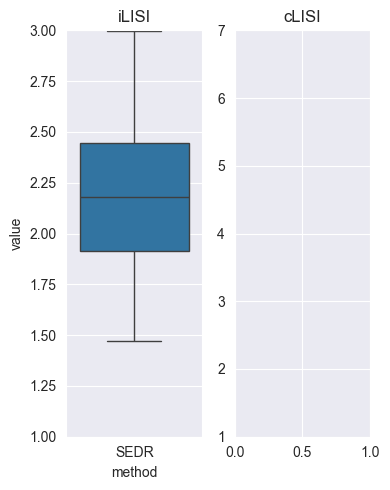

In [12]:
import harmonypy as hm

iLISI = hm.compute_lisi(batch_adata.obsm['Harmony_Revised'], batch_adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
#cLISI = hm.compute_lisi(adata.obsm['SEDR'], adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]
df_iLISI = pd.DataFrame({
    'method': 'SEDR',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

# df_cLISI = pd.DataFrame({
#     'method': 'SEDR',
#     'value': cLISI,
#     'type': ['CLISI'] * len(cLISI)
# })

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
#sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
#print(np.median(cLISI))

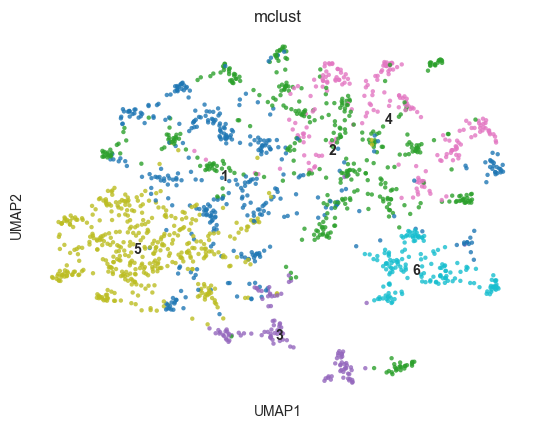

In [13]:
plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色
import scanpy as sc
import matplotlib.pyplot as plt

sc.pp.neighbors(batch_adata, use_rep='Harmony_Revised', metric='cosine', n_neighbors=15)  # 可调整 n_neighbors
sc.tl.umap(batch_adata)  # 调整 min_dist 参数优化聚类

sc.pl.umap(
    batch_adata,
    color=['mclust'],
    size=40,  # 调整点大小
    alpha=0.8,  # 调整透明度
    palette='tab10',  # 自定义调色板
    legend_loc='on data'
)

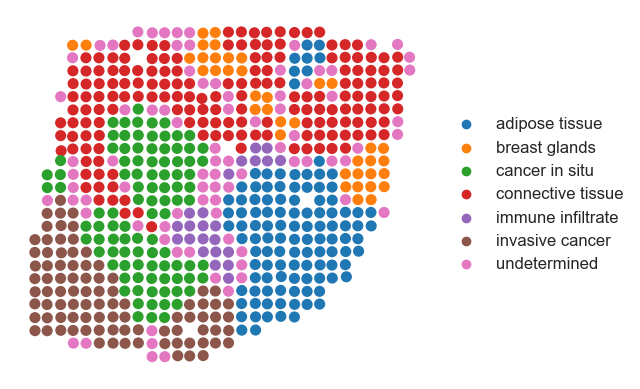

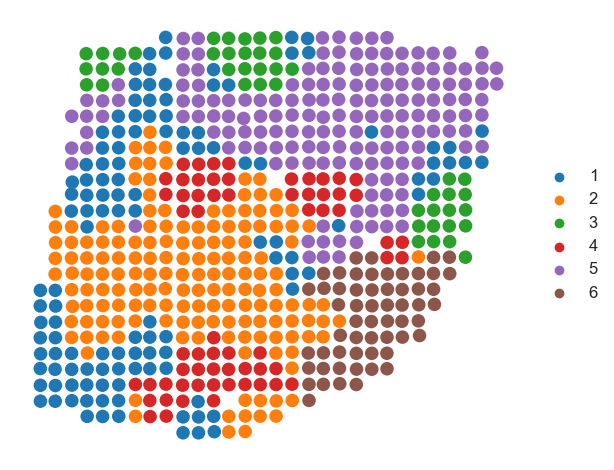

In [14]:
import matplotlib.pyplot as plt


adata_tmp_A1 = batch_adata[batch_adata.obs['batch_name'] == String+str(1)]
adata_tmp_A1.uns = adata_st_list_raw[1].uns

sc.pl.spatial(adata_tmp_A1, img_key='hires', color=['annotation'], title=[''],
              legend_loc='right margin', legend_fontsize=12, show=False, frameon=False, spot_size=250)

sc.pl.spatial(adata_tmp_A1, img_key='hires', color=['mclust'], title=[''],
              legend_loc='right margin', legend_fontsize=12, show=False, frameon=False, spot_size=250)

# sc.pl.scatter(adata_tmp_A1, 
#               x='x',  # 这里假设你的空间坐标 x 存储在 'spatial_x' 列中
#               y='y',  # 这里假设你的空间坐标 y 存储在 'spatial_y' 列中
#               color='annotation',  # 设置颜色为注释（annotation）
#               title='',  # 设置标题为空
#               legend_loc='right margin',  # 设置图例位置
#               legend_fontsize=12,  # 设置图例字体大小
#               show=False,  # 不自动显示图形
#               frameon=False)  # 不显示边框

# sc.pl.scatter(adata_tmp_A1, 
#               x='x',  # 这里假设你的空间坐标 x 存储在 'spatial_x' 列中
#               y='y',  # 这里假设你的空间坐标 y 存储在 'spatial_y' 列中
#               color='mclust',  # 设置颜色为注释（annotation）
#               title='',  # 设置标题为空
#               legend_loc='right margin',  # 设置图例位置
#               legend_fontsize=12,  # 设置图例字体大小
#               show=False,  # 不自动显示图形
#               frameon=False)  # 不显示边框

plt.tight_layout()

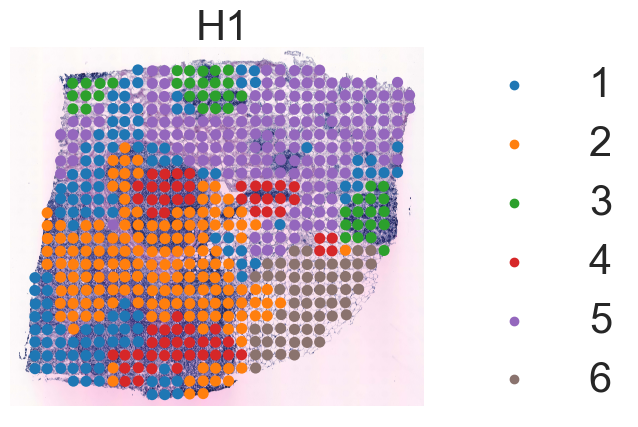

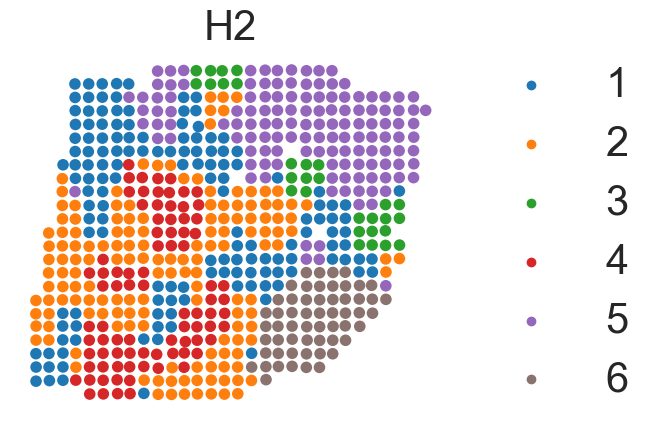

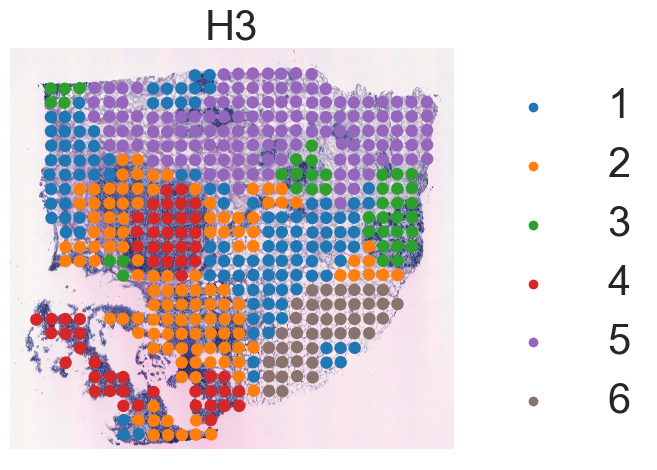

In [16]:
import matplotlib.pyplot as plt

cluster_colors = {
    1: '#1f77b4',  # Cluster 0 -> 蓝色
    2: '#ff7f0e',  # Cluster 1 -> 橙色
    3: '#2ca02c',  # Cluster 2 -> 绿色
    4: '#d62728',  # Cluster 3 -> 红色
    5: '#9467bd',  # Cluster 4 -> 紫色
    6: '#8a736e'   # Cluster 5 -> 
}


for i, slice_name in enumerate(slice_use):
    adata_tmp = batch_adata[batch_adata.obs['batch_name'] == String+str(i+1)]
    adata_tmp.uns = adata_st_list_raw[i].uns
    sc.pl.spatial(adata_tmp, img_key='hires', color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=30, show=False, frameon=False, spot_size=250,
                  palette=cluster_colors)
    plt.title(f'{slice_name}', fontsize=30)
    plt.savefig(f"D:\\njy\MutipelSliceSTD\MS\论文图表设计\Figure8_BC\FS12\\{String}\SpaGIC_{i+1}.jpg", dpi=300, bbox_inches='tight')
plt.tight_layout()